In [2]:
# Math
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

import shap

import mlflow
import mlflow.sklearn

# Predictive Modeling of Electric Vehicle Battery Degradation

## 1. Problem Formulation & Significance
As global electric vehicle (EV) adoption accelerates, accurately forecasting the Remaining Useful Life (RUL) and State of Health (SoH) of lithium-ion batteries is critical for vehicle valuation, warranty provisioning, and predictive maintenance. 

The two dominant battery chemistries: Nickel Manganese Cobalt (NMC) and Lithium Iron Phosphate (LFP), exhibit distinct degradation profiles under varying thermal and operational stresses. 

**Objective:**
This project transitions from exploratory data science into predictive machine learning. We aim to construct and evaluate multivariable models capable of predicting battery degradation. Because degradation modeling is highly susceptible to "feature dominance" (where algorithms rely entirely on obvious symptoms rather than underlying causes), we will conduct a three-part experiment:
1. **Baseline Modeling:** Predicting absolute SoH using all available telemetry and diagnostic data.
2. **Feature Ablation:** Removing direct diagnostic symptoms to force models to evaluate historical usage.
3. **Target Transformation:** Shifting the mathematical target from absolute capacity to a cycle-weighted degradation rate to uncover complex multivariable dependencies.

### 1.1 Dataset Assumptions & Constraints
**Disclaimer:** The dataset utilized in this project (`ev_battery_degradation_v1.csv`) is a synthetic dataset generated using a semi-empirical degradation model. 
* While it accurately reflects real-world physics, synthetic generation algorithms inherently hardcode strong linear correlations between primary variables (like Total Cycles) and the target variable (SoH). 
* A key focus of our machine learning methodology will be mitigating this synthetic linearity to prove our models can identify secondary, non-linear operational stresses (like fast-charging ratios and driving styles).

### 1.2 Mathematical Definition of the Baseline Target
In our initial phase, the target variable is the absolute State of Health ($SoH$), expressed as a percentage of the battery's original factory capacity. 

Let $C_{current}$ be the currently measurable capacity in kWh, and $C_{nominal}$ be the original capacity. 

$$SoH = \left( \frac{C_{current}}{C_{nominal}} \right) \times 100$$

In [3]:
data_path = 'data/ev_battery_degradation_v1.csv'
battery_data = pd.read_csv(data_path)

In [4]:
battery_data.shape

(10000, 13)

In [5]:
battery_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Vehicle_ID               10000 non-null  object 
 1   Car_Model                10000 non-null  object 
 2   Battery_Type             10000 non-null  object 
 3   Battery_Capacity_kWh     10000 non-null  float64
 4   Vehicle_Age_Months       10000 non-null  int64  
 5   Total_Charging_Cycles    10000 non-null  int64  
 6   Avg_Temperature_C        10000 non-null  float64
 7   Fast_Charge_Ratio        10000 non-null  float64
 8   Avg_Discharge_Rate_C     10000 non-null  float64
 9   Driving_Style            10000 non-null  object 
 10  Internal_Resistance_Ohm  10000 non-null  float64
 11  SoH_Percent              10000 non-null  float64
 12  Battery_Status           10000 non-null  object 
dtypes: float64(6), int64(2), object(5)
memory usage: 1015.8+ KB


## 2. Data Preparation & Feature Engineering

To prepare our dataset for machine learning algorithms, we must translate all categorical string data into mathematical representations. Before deciding on an encoding strategy, we first need to isolate our non-numeric columns and inspect their unique values and cardinality.

In [6]:
# Isolate columns with 'object' (string) data types
categorical_cols = battery_data.select_dtypes(include=['object']).columns

print("Categorical Columns and their Unique Values:\n" + "-"*45)

for col in categorical_cols:
    unique_vals = battery_data[col].unique()
    print(f"{col} ({len(unique_vals)} unique categories):")
    print(f"  {unique_vals}\n")

Categorical Columns and their Unique Values:
---------------------------------------------
Vehicle_ID (10000 unique categories):
  ['1fb46ae8' 'b7ef35aa' '76cb49e0' ... '3c549739' 'a6c88d13' '9e50c2e0']

Car_Model (5 unique categories):
  ['Tesla Model 3' 'Ford Mustang Mach-E' 'Hyundai Ioniq 5' 'Wuling Air EV'
 'BYD Atto 3']

Battery_Type (2 unique categories):
  ['NMC' 'LFP']

Driving_Style (3 unique categories):
  ['Aggressive' 'Conservative' 'Moderate']

Battery_Status (2 unique categories):
  ['Healthy' 'Replace Required']



Based on the programmatic inspection above, the encoding strategy depends heavily on the nature and cardinality of the variable to prevent introducing false mathematical relationships into our linear models.

* **Identifier Removal:** The `Vehicle_ID` column is completely unique to each row and will be dropped to prevent models from memorizing specific instances instead of learning generalized patterns.
* **Binary Encoding:** `Battery_Type` (NMC/LFP) and `Battery_Status` (Healthy/Replace Required) are binary. We will utilize `scikit-learn`'s `LabelEncoder` to map these to 0 and 1.
* **Ordinal Encoding:** `Driving_Style` has a strict hierarchical order (Conservative < Moderate < Aggressive). We will use a custom dictionary mapping to preserve this magnitude.
* **Nominal Encoding (Low Cardinality):** `Car_Model` contains 5 discrete categories with no numerical relationship. We will apply One-Hot Encoding (using `drop_first=True` to avoid the dummy variable trap) to prevent linear algorithms from assuming an ordinal hierarchy. 

In [7]:
# 1. Drop the unique identifier
battery_data = battery_data.drop(columns=['Vehicle_ID'])
print("Dropped Vehicle_ID column.")

# 2. Initialize LabelEncoders for binary columns
le_battery = LabelEncoder()
le_status = LabelEncoder()

# Apply Label Encoding
battery_data['Battery_Type_Encoded'] = le_battery.fit_transform(battery_data['Battery_Type'])
battery_data['Battery_Status_Encoded'] = le_status.fit_transform(battery_data['Battery_Status'])

# Print the mapping to prove we know what the model is doing
print("\nLabel Encoder Mappings:")
print(f"Battery_Type: {dict(zip(le_battery.classes_, le_battery.transform(le_battery.classes_)))}")
print(f"Battery_Status: {dict(zip(le_status.classes_, le_status.transform(le_status.classes_)))}")

# Drop the original text columns to keep the dataframe clean
battery_data = battery_data.drop(columns=['Battery_Type', 'Battery_Status'])

Dropped Vehicle_ID column.

Label Encoder Mappings:
Battery_Type: {'LFP': np.int64(0), 'NMC': np.int64(1)}
Battery_Status: {'Healthy': np.int64(0), 'Replace Required': np.int64(1)}


In [8]:
# 3. Ordinal Encoding for Driving Style
driving_mapping = {'Conservative': 0, 'Moderate': 1, 'Aggressive': 2}
battery_data['Driving_Style_Encoded'] = battery_data['Driving_Style'].map(driving_mapping)
battery_data = battery_data.drop(columns=['Driving_Style'])
print("Applied ordinal mapping to Driving_Style.")

# 4. One-Hot Encoding for Car Model
# We use drop_first=True to avoid the "dummy variable trap" (perfect multicollinearity)
battery_data = pd.get_dummies(battery_data, columns=['Car_Model'], drop_first=True, dtype=int)
print(f"Applied One-Hot Encoding to Car_Model.")

# Check the new shape and columns
print(f"\nNew dataset shape: {battery_data.shape}")
display(battery_data.head(10))

Applied ordinal mapping to Driving_Style.
Applied One-Hot Encoding to Car_Model.

New dataset shape: (10000, 15)


,Battery_Capacity_kWh,Vehicle_Age_Months,Total_Charging_Cycles,Avg_Temperature_C,Fast_Charge_Ratio,Avg_Discharge_Rate_C,Internal_Resistance_Ohm,SoH_Percent,Battery_Type_Encoded,Battery_Status_Encoded,Driving_Style_Encoded,Car_Model_Ford Mustang Mach-E,Car_Model_Hyundai Ioniq 5,Car_Model_Tesla Model 3,Car_Model_Wuling Air EV
0,75.0,41,390,21.5,0.51,2.22,0.0362,94.60,1,0,2,0,0,1,0
1,75.0,29,401,18.0,0.62,1.34,0.0333,95.68,1,0,2,0,0,1,0
2,88.0,71,941,18.4,0.78,1.48,0.0526,89.80,1,0,0,1,0,0,0
3,88.0,57,378,10.8,0.61,0.72,0.0314,96.29,1,0,1,1,0,0,0
4,75.0,58,239,30.3,0.89,1.48,0.0297,96.75,1,0,0,0,0,1,0
5,72.6,27,225,20.0,0.35,2.50,0.0265,98.07,1,0,1,0,1,0,0
6,72.6,49,734,3.2,0.51,0.65,0.0401,94.20,1,0,0,0,1,0,0
7,72.6,12,121,27.4,0.29,1.41,0.0223,98.76,1,0,1,0,1,0,0
8,88.0,40,170,23.7,0.71,1.23,0.0236,98.53,1,0,0,1,0,0,0
9,26.0,12,100,19.6,0.59,1.50,0.0208,100.00,0,0,0,0,0,0,1


## 3. Unsupervised Learning: Anomaly Detection via DBSCAN

Before constructing predictive models, it is crucial to identify any severe outliers. In real-world telemetry, outliers represent critical events such as early-onset thermal runaway or extreme driving behaviors.

We will apply **DBSCAN**. Because it is highly sensitive to its hyperparameters (`eps` and `min_samples`), we will not select these arbitrarily:
1. `min_samples = 10`: Because our synthetic dataset (Section 1.1) lacks physical sensor errors, the dataset represents continuous mathematical distributions. We know these points are valid synthetic variance; however, we want to isolate the extreme tails of these distributions. By setting a strict density threshold (10 points) to define our "normal" cluster, we intentionally force the algorithm to exclude the extreme mathematical edge-cases, flagging them as anomalous so they do not skew our subsequent linear models.
2. `eps` Selection: We will utilize the **Elbow Method (K-Distance Graph)** to empirically determine the optimal search radius.

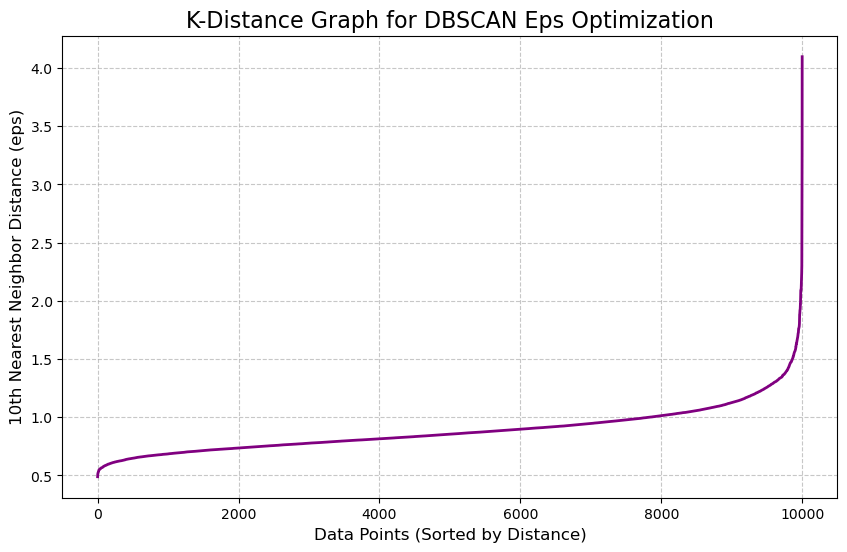

In [9]:
# 1. Isolate the continuous numerical features for clustering
continuous_features = [
    'Battery_Capacity_kWh', 'Vehicle_Age_Months', 'Total_Charging_Cycles', 
    'Avg_Temperature_C', 'Fast_Charge_Ratio', 'Avg_Discharge_Rate_C', 
    'Internal_Resistance_Ohm', 'SoH_Percent'
]

# 2. Standardize the data (Mean=0, Variance=1)
scaler = StandardScaler()
scaled_continuous_data = scaler.fit_transform(battery_data[continuous_features])

# 3. Find optimal eps using the K-Distance Graph (Nearest Neighbors)
neighbors = NearestNeighbors(n_neighbors=10) # Aligned with our chosen min_samples
neighbors_fit = neighbors.fit(scaled_continuous_data)
distances, indices = neighbors_fit.kneighbors(scaled_continuous_data)

# Sort and plot distances
distances = np.sort(distances[:, 9], axis=0) # Index 9 corresponds to the 10th neighbor

plt.figure(figsize=(10, 6))
plt.plot(distances, color='purple', linewidth=2)
plt.title("K-Distance Graph for DBSCAN Eps Optimization", fontsize=16)
plt.xlabel("Data Points (Sorted by Distance)", fontsize=12)
plt.ylabel("10th Nearest Neighbor Distance (eps)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Hyperparameter Selection:**
Observing the K-Distance graph above, the curve remains relatively stable before bending sharply upward. This "elbow" occurs at approximately **1.3** on the Y-axis. 

This mathematically represents the optimal `eps` search radius to pair with our strict `min_samples = 10` threshold. Distances below 1.3 encapsulate the densely packed, central "normal" distributions of our synthetic data. The sudden spike beyond 1.3 represents the sparse, extreme mathematical edge-cases. By setting `eps = 1.3`, we precisely define the boundary that pushes these extreme synthetic variances out of the main cluster, ensuring they are correctly flagged as anomalous.

Using an optimized eps of 1.3, DBSCAN identified 90 anomalous profiles.


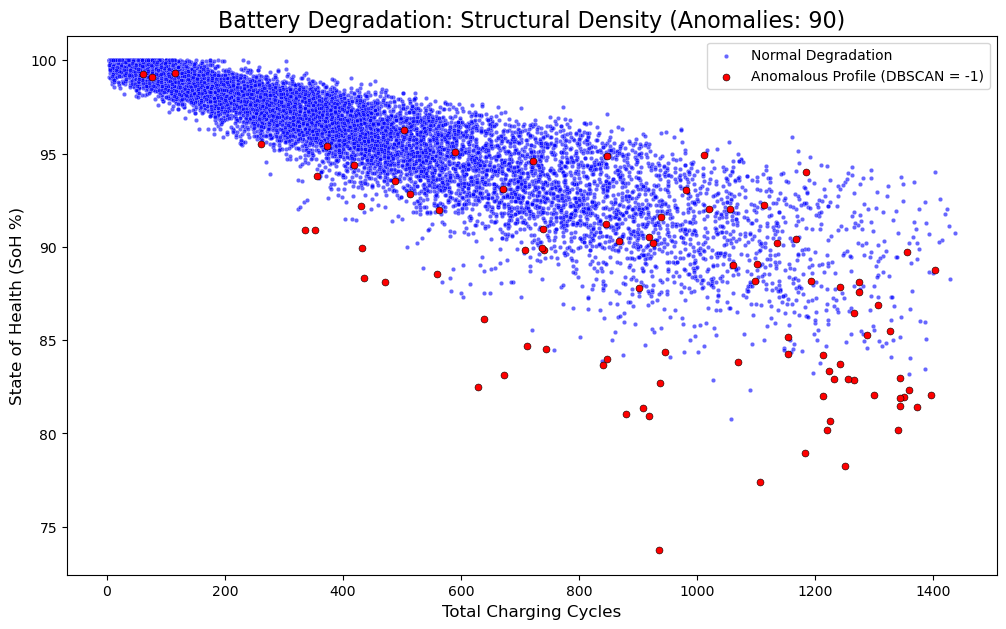

In [10]:
# 4. Initialize and fit DBSCAN using mathematically derived parameters
optimal_eps = 1.3
dbscan = DBSCAN(eps=optimal_eps, min_samples=10)
battery_data['Anomaly_Cluster'] = dbscan.fit_predict(scaled_continuous_data)

# Calculate how many anomalies were found
total_anomalies = (battery_data['Anomaly_Cluster'] == -1).sum()
print(f"Using an optimized eps of {optimal_eps}, DBSCAN identified {total_anomalies} anomalous profiles.")

# 5. Visualize the Distribution
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=battery_data[battery_data['Anomaly_Cluster'] != -1], 
    x='Total_Charging_Cycles', 
    y='SoH_Percent', 
    color='blue',
    s=10,
    alpha=0.6, 
    label='Normal Degradation'
)

if total_anomalies > 0:
    sns.scatterplot(
        data=battery_data[battery_data['Anomaly_Cluster'] == -1], 
        x='Total_Charging_Cycles', 
        y='SoH_Percent', 
        color='red', 
        s=25, 
        edgecolor='black',
        label='Anomalous Profile (DBSCAN = -1)'
    )

plt.title(f'Battery Degradation: Structural Density (Anomalies: {total_anomalies})', fontsize=16)
plt.xlabel('Total Charging Cycles', fontsize=12)
plt.ylabel('State of Health (SoH %)', fontsize=12)
plt.legend()
plt.show()

### 3.1 Unsupervised Learning Conclusion

Using an empirically optimized `eps` of 1.3, DBSCAN successfully scanned the multi-dimensional feature space and identified **90 anomalous profiles** (approximately 0.9% of the total dataset).

While our synthetic dataset (Section 1.1) inherently lacks catastrophic physical failures, these 90 points represent the extreme mathematical edge-cases of the generative distributions - such as highly improbable overlaps of maximum driving aggression, extreme environmental temperatures, and maximal charge cycles. 

By identifying and isolating these extreme profiles, we can confidently proceed to supervised predictive modeling, ensuring that these rare edge-cases do not exert disproportionate mathematical leverage and skew the weights of our Baseline Linear Regression model.

## 4. Supervised Learning: Baseline Regression & MLOps Tracking

With our dataset fully numeric, scaled, and the structural anomalies identified, we now transition to predictive modeling. Our first objective is **Regression**: predicting the exact continuous value of the battery's State of Health (`SoH_Percent`).

To ensure our experimentation is reproducible and structurally sound, we will integrate **MLflow** directly into our training pipeline. Rather than tracking model parameters and evaluation metrics manually, MLflow will act as our local model registry.

**The Baseline Strategy:**
We will begin with an Ordinary Least Squares (OLS) Linear Regression model. 
* *Note on Feature Selection:* As identified in Chapter 2, there is heavy multicollinearity between `Battery_Type` and `Car_Model`. We will intentionally retain `Car_Model` in our initial Run 0 to empirically demonstrate how linear weights become unstable when proxy variables are present, before removing it for our optimized Run 1.

In [11]:
# 1. Final Data Preparation for Modeling
# Filter out the 90 anomalies we found in Chapter 3
clean_data = battery_data[battery_data['Anomaly_Cluster'] != -1].copy()

# Drop 'Anomaly_Cluster' and 'Battery_Status_Encoded' (Target Leak)
# If we keep 'Battery_Status', the model cheats because "Replace Required" directly means low SoH.
clean_data = clean_data.drop(columns=['Anomaly_Cluster', 'Battery_Status_Encoded'])

# Define our Target (y) and Features (X)
y = clean_data['SoH_Percent']
X_with_cars = clean_data.drop(columns=['SoH_Percent'])

# Train/Test Split (80% training, 20% testing)
X_train_c, X_test_c, y_train, y_test = train_test_split(X_with_cars, y, test_size=0.2, random_state=42)

# 2. Initialize MLflow Experiment
mlflow.set_experiment("EV_Battery_Degradation_Baseline")

# 3. MLflow Run 0: Baseline OLS (With Multicollinearity)
with mlflow.start_run(run_name="Run_0_OLS_With_Car_Models"):
    
    # Initialize and train model
    ols_model_0 = LinearRegression()
    ols_model_0.fit(X_train_c, y_train)
    
    # Predictions
    y_pred_c = ols_model_0.predict(X_test_c)
    
    # Calculate Metrics
    rmse_0 = np.sqrt(mean_squared_error(y_test, y_pred_c))
    r2_0 = r2_score(y_test, y_pred_c)
    
    # Log to MLflow
    mlflow.log_param("model_type", "Ordinary Least Squares")
    mlflow.log_param("features_included", "All (including Car Models)")
    mlflow.log_metric("RMSE", rmse_0)
    mlflow.log_metric("R2_Score", r2_0)
    mlflow.sklearn.log_model(ols_model_0, "model")
    
    print(f"--- RUN 0: OLS WITH CAR MODELS ---")
    print(f"RMSE: {rmse_0:.4f}")
    print(f"R-Squared: {r2_0:.4f}")
    
    # Print the coefficients (weights)
    print("\nModel Coefficients:")
    coefficients = pd.DataFrame({'Feature': X_with_cars.columns, 'Weight': ols_model_0.coef_})
    display(coefficients.sort_values(by='Weight', ascending=False))

2026/06/22 22:35:58 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Cmd('git') failed due to: exit code(1)
  cmdline: git version
  stderr: 'xcode-select: note: No developer tools were found, requesting install.
If developer tools are located at a non-default location on disk, use `sudo xcode-select --switch path/to/Xcode.app` to specify the Xcode that you wish to use for command line developer tools, and cancel the installation dialog.
See `man xcode-select` for more details.'
2026/06/22 22:35:58 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git branch is not available. Error: Failed to initialize: Cmd('git') failed due to: exit code(1)
  cmdline: git version
  stderr: 'xcode-select: note: No developer tools were found, requesting install.
If developer tools are located at a non-default location on disk, use `sud

--- RUN 0: OLS WITH CAR MODELS ---
RMSE: 0.3847
R-Squared: 0.9845

Model Coefficients:


,Feature,Weight
7,Battery_Type_Encoded,0.182365
12,Car_Model_Wuling Air EV,0.090602
10,Car_Model_Hyundai Ioniq 5,0.073867
11,Car_Model_Tesla Model 3,0.068146
9,Car_Model_Ford Mustang Mach-E,0.040353
0,Battery_Capacity_kWh,0.002299
1,Vehicle_Age_Months,-0.000676
2,Total_Charging_Cycles,-0.002913
3,Avg_Temperature_C,-0.014428
5,Avg_Discharge_Rate_C,-0.014643


### 4.1 Feature Optimization: Resolving Multicollinearity

Evaluating the coefficients from **Run 0**, we can observe a mathematical dilution occurring between our categorical features. 

This empirically validates our hypothesis from Chapter 2 regarding **Multicollinearity**. Because specific car models in this dataset act as direct proxies for specific battery chemistries, the Ordinary Least Squares (OLS) algorithm struggles to isolate the variance. Instead of assigning the full predictive weight to the underlying chemistry (`Battery_Type_Encoded`), the model artificially splits and dilutes that weight across the redundant `Car_Model` columns.

To resolve this collinearity and consolidate the mathematical weights where they belong, we performed feature ablation on the `Car_Model` columns for **Run 1**. The resulting optimized baseline shows the weight for `Battery_Type_Encoded` successfully stabilizing at a higher, more representative value.

In [12]:
# 1. Feature Ablation: Drop the redundant Car Model columns
car_columns = [col for col in clean_data.columns if 'Car_Model' in col]
X_optimized = clean_data.drop(columns=['SoH_Percent'] + car_columns)

# Re-split the clean data
X_train_opt, X_test_opt, y_train, y_test = train_test_split(X_optimized, y, test_size=0.2, random_state=42)

# 2. MLflow Run 1: Optimized OLS
with mlflow.start_run(run_name="Run_1_OLS_Optimized"):
    
    # Initialize and train model
    ols_model_1 = LinearRegression()
    ols_model_1.fit(X_train_opt, y_train)
    
    # Predictions
    y_pred_opt = ols_model_1.predict(X_test_opt)
    
    # Calculate Metrics
    rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred_opt))
    r2_1 = r2_score(y_test, y_pred_opt)
    
    # Log to MLflow
    mlflow.log_param("model_type", "Ordinary Least Squares")
    mlflow.log_param("features_included", "Optimized (Car Models Removed)")
    mlflow.log_metric("RMSE", rmse_1)
    mlflow.log_metric("R2_Score", r2_1)
    mlflow.sklearn.log_model(ols_model_1, "model")
    
    print(f"--- RUN 1: OPTIMIZED OLS BASELINE ---")
    print(f"RMSE: {rmse_1:.4f}")
    print(f"R-Squared: {r2_1:.4f}")
    print("\nOptimized Model Coefficients:")
    optimized_coeffs = pd.DataFrame({'Feature': X_optimized.columns, 'Weight': ols_model_1.coef_})
    display(optimized_coeffs.sort_values(by='Weight', ascending=False))

2026/06/22 22:36:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


--- RUN 1: OPTIMIZED OLS BASELINE ---
RMSE: 0.3848
R-Squared: 0.9845

Optimized Model Coefficients:


,Feature,Weight
7,Battery_Type_Encoded,0.289147
0,Battery_Capacity_kWh,-0.000270
1,Vehicle_Age_Months,-0.000679
2,Total_Charging_Cycles,-0.002913
3,Avg_Temperature_C,-0.014427
5,Avg_Discharge_Rate_C,-0.014694
8,Driving_Style_Encoded,-0.185567
4,Fast_Charge_Ratio,-0.563376
6,Internal_Resistance_Ohm,-246.627548


### 4.2 Feature Ablation on direct diagnostic symptoms

While our optimized baseline (Run 1) yielded an exceptionally high $R^2$ score of 0.9845, a critical examination of the model's coefficients reveals a fundamental structural limitation for long-term predictive use. 

The model is heavily dominated by a single feature: `Internal_Resistance_Ohm` (carrying a massive weight of -246.62). 

In battery physics, internal resistance is not a *cause* of degradation; it is an active *symptom* of it. As the battery's internal health declines, its resistance naturally climbs. Because this physical sensor reading acts as a near-perfect proxy for State of Health (`SoH_Percent`), the Ordinary Least Squares (OLS) algorithm effectively "cheats." It relies almost exclusively on this single dominant symptom to calculate the answer, while completely ignoring the actual historical usage data.

To transform this into a robust predictive model that can evaluate how driving behavior and charging habits impact battery longevity, we must execute a **Feature Ablation Experiment**. 

By deliberately stripping `Internal_Resistance_Ohm` out of the dataset for **Run 2**, we will mathematically blind the model to the physical symptom. This will force the regression algorithm to re-evaluate the remaining features and uncover the true weight of the operational root causes such as fast-charging ratios, temperature exposure, and driving styles. 

While we expect our global metrics ($R^2$ and RMSE) to humanize and drop from their near-perfect baseline levels, this step is essential to isolate the actionable degradation drivers required to satisfy our primary research goals.

In [13]:
# 1. Feature Ablation: Drop the 'Internal_Resistance_Ohm' symptom
# We keep the optimized X_optimized dataframe but remove the dominant symptom
X_ablation = X_optimized.drop(columns=['Internal_Resistance_Ohm'])

# Re-split the data
X_train_abl, X_test_abl, y_train, y_test = train_test_split(X_ablation, y, test_size=0.2, random_state=42)

# 2. MLflow Run 2: Feature Ablation (Usage-Focused)
with mlflow.start_run(run_name="Run_2_Ablation_Usage_Only"):
    
    # Initialize and train model
    ols_model_2 = LinearRegression()
    ols_model_2.fit(X_train_abl, y_train)
    
    # Predictions
    y_pred_abl = ols_model_2.predict(X_test_abl)
    
    # Calculate Metrics
    rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_abl))
    r2_2 = r2_score(y_test, y_pred_abl)
    
    # Log to MLflow
    mlflow.log_param("model_type", "Ordinary Least Squares")
    mlflow.log_param("features_included", "Usage Features Only (No Internal Resistance)")
    mlflow.log_metric("RMSE", rmse_2)
    mlflow.log_metric("R2_Score", r2_2)
    mlflow.sklearn.log_model(ols_model_2, "model")
    
    print(f"--- RUN 2: FEATURE ABLATION ---")
    print(f"RMSE: {rmse_2:.4f}")
    print(f"R-Squared: {r2_2:.4f}")
    print("\nAblated Model Coefficients:")
    ablation_coeffs = pd.DataFrame({'Feature': X_ablation.columns, 'Weight': ols_model_2.coef_})
    display(ablation_coeffs.sort_values(by='Weight', ascending=False))

2026/06/22 22:36:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


--- RUN 2: FEATURE ABLATION ---
RMSE: 0.9742
R-Squared: 0.9009

Ablated Model Coefficients:


,Feature,Weight
0,Battery_Capacity_kWh,-0.000094
1,Vehicle_Age_Months,-0.001361
2,Total_Charging_Cycles,-0.008693
5,Avg_Discharge_Rate_C,-0.033234
3,Avg_Temperature_C,-0.042642
7,Driving_Style_Encoded,-0.589165
4,Fast_Charge_Ratio,-1.612529
6,Battery_Type_Encoded,-1.769546


### 4.3 Conclusion of the Linear Baseline (OLS)

The feature ablation experiment (Run 2) yielded an $R^2$ of 0.9009 and an RMSE of 0.9742. While this is a mathematical decrease from our initial "symptom-heavy" baseline, it represents a significantly more honest predictive model. It proves that historical usage features, such as fast-charging habits, driving style, and temperature exposure, successfully explain approximately 90% of the variance in a battery's State of Health (SoH). 

*Note on Synthetic Data Dynamics:* Real-world battery degradation typically follows a non-linear "S-curve" (a sharp initial drop, a long stable plateau, and a rapid end-of-life decline). The fact that an Ordinary Least Squares (OLS) algorithm achieved a 0.90 $R^2$ suggests this synthetic dataset relies on a predominantly linear baseline degradation formula.

However, OLS has reached its theoretical limit for our specific research objectives. OLS models evaluate features in strict isolation, apply static linear penalties and cannot capture complex multivariable dependencies.

**Next Steps:**
To accurately isolate behavioral degradation and evaluate feature interactions, we must pivot our methodology:
1. **Target Transformation:** We will engineer a new target variable (`Degradation_per_Cycle`) to mathematically neutralize the absolute age of the battery.
2. **Algorithmic Shift:** We will transition to a non-linear, tree-based algorithm (Random Forest Regressor) capable of mapping complex feature interactions and conditional logic.

## 5. Target Transformation 

As established in our OLS baseline conclusion, predicting the absolute State of Health (`SoH_Percent`) as reached its theoretical limit for our specific research objectives by forcing the model to heavily weight the sheer volume of a battery's age (`Total_Charging_Cycles`) in our case. This mathematical dominance obscures the nuanced behavioral impacts we aim to study.

In this phase, we will transform our target variable from **Absolute Health** to a **Rate of Decay**. By calculating the `Degradation_per_Cycle`, we shift the algorithm's focus: instead of evaluating how old a battery is, the model will evaluate how much micro-damage was inflicted during a single charging cycle under specific conditions.

In [14]:
# 1. Engineer the New Target Variable: Degradation per Cycle
clean_data['Total_Degradation'] = 100.0 - clean_data['SoH_Percent']

# Calculate micro-damage per cycle. 
clean_data['Degradation_per_Cycle'] = clean_data['Total_Degradation'] / clean_data['Total_Charging_Cycles'].clip(lower=1)

# 2. Feature Selection for Phase 3 (The Final Matrix)
cols_to_drop = [
    'SoH_Percent',
    'Total_Degradation',
    'Internal_Resistance_Ohm',
    'Total_Charging_Cycles',
    'Degradation_per_Cycle'
]

# Append the redundant car models
car_columns = [col for col in clean_data.columns if 'Car_Model' in col]
cols_to_drop.extend(car_columns)

# Create final Feature Matrix (X) and Target (y)
X_rf = clean_data.drop(columns=cols_to_drop)
y_rf = clean_data['Degradation_per_Cycle']

print(f"Final Feature Matrix Shape: {X_rf.shape}")

# Display the new correlation landscape
print("\nFeature Correlations with Degradation_per_Cycle:")
display(X_rf.corrwith(y_rf).sort_values(ascending=False))

Final Feature Matrix Shape: (9910, 7)

Feature Correlations with Degradation_per_Cycle:


Battery_Type_Encoded     0.256523
Battery_Capacity_kWh     0.210367
Driving_Style_Encoded    0.135139
Fast_Charge_Ratio        0.132265
Avg_Temperature_C        0.118099
Avg_Discharge_Rate_C     0.000508
Vehicle_Age_Months      -0.107200
dtype: float64

### 5.1 Analysis of the Transformed Target

By neutralizing the absolute age of the battery (`Total_Charging_Cycles`), the correlation landscape has shifted from a measure of total wear to a measure of **degradation intensity**. We are no longer quantifying the cumulative loss of capacity, but rather the rate at which micro-damage is accumulated per charging session.

With a final feature matrix of 7 dimensions (9,910 observations), our correlation analysis against `Degradation_per_Cycle` reveals the following drivers of battery health:

* **Primary Drivers:** `Battery_Type_Encoded` (0.256) and `Battery_Capacity_kWh` (0.210) exhibit the strongest positive correlations with the rate of decay. This suggests that specific battery architectures and capacities inherently influence the speed at which degradation occurs.
* **Operational Behaviors:** `Driving_Style_Encoded` (0.135) and `Fast_Charge_Ratio` (0.132) confirm that aggressive usage patterns and high-power charging accelerate the degradation rate, consistent with electrochemical fatigue in lithium-ion systems.
* **Environmental & Temporal Factors:** `Avg_Temperature_C` (0.118) shows a moderate impact, while `Vehicle_Age_Months` (-0.107) shows a negative correlation, suggesting that, when normalized for cycle count, the degradation rate per cycle slightly stabilizes or shifts as the vehicle matures.
* **Negligible Drivers:** `Avg_Discharge_Rate_C` (0.0005) shows almost no linear correlation with the rate of degradation, indicating that for this specific dataset, continuous discharge rates are not a primary driver of cycle-based decay.

**Moving Toward Non-Linear Modeling:**
While these correlations provide an excellent overview, their moderate strength suggests that degradation is not a product of isolated linear inputs. Instead, it is likely the result of complex interactions (e.g., how elevated temperatures compound the damage caused by fast charging). To capture these interdependencies and improve our predictive accuracy, we will now transition to a **Random Forest Regressor**, which is better suited for mapping the conditional, non-linear dynamics of battery degradation.

### 5.2 Training the Non-Linear Model (Random Forest)

Having engineered our `Degradation_per_Cycle` target, we now deploy a **Random Forest Regressor**. 

Unlike Ordinary Least Squares, a Random Forest operates by constructing an ensemble of decision trees. This architecture inherently captures non-linear relationships and complex feature interactions, such as evaluating how specific battery chemistries react to high temperatures under fast-charging conditions. By predicting the degradation rate per cycle, we neutralize the overpowering effect of absolute vehicle age and force the algorithm to evaluate true operational wear and tear.

In [15]:
# 1. Train/Test Split on the Final Feature Matrix
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# 2. MLflow Run 3: Random Forest Regressor
with mlflow.start_run(run_name="Run_3_Random_Forest_Rate"):
    
    # Initialize and train model (using 100 decision trees)
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train_rf, y_train_rf)
    
    # Predictions
    y_pred_rf = rf_model.predict(X_test_rf)
    
    # Calculate Metrics
    rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
    mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
    r2_rf = r2_score(y_test_rf, y_pred_rf)
    
    # Log to MLflow
    mlflow.log_param("model_type", "Random Forest Regressor")
    mlflow.log_param("target_variable", "Degradation_per_Cycle")
    mlflow.log_metric("RMSE", rmse_rf)
    mlflow.log_metric("MAE", mae_rf)
    mlflow.log_metric("R2_Score", r2_rf)
    mlflow.sklearn.log_model(rf_model, "model")
    
    print(f"--- RUN 3: RANDOM FOREST (DEGRADATION RATE) ---")
    print(f"RMSE: {rmse_rf:.6f}")
    print(f"MAE:  {mae_rf:.6f}")
    print(f"R-Squared: {r2_rf:.4f}")
    
    # Extract and display Feature Importances
    print("\nRandom Forest Feature Importances:")
    rf_importances = pd.DataFrame({
        'Feature': X_rf.columns, 
        'Importance': rf_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    # Format the importances as percentages for easier reading
    rf_importances['Importance'] = (rf_importances['Importance'] * 100).map("{:.2f}%".format)
    display(rf_importances)

2026/06/22 22:36:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


--- RUN 3: RANDOM FOREST (DEGRADATION RATE) ---
RMSE: 0.006486
MAE:  0.002320
R-Squared: 0.2037

Random Forest Feature Importances:


,Feature,Importance
2,Avg_Temperature_C,23.20%
1,Vehicle_Age_Months,20.57%
3,Fast_Charge_Ratio,19.43%
4,Avg_Discharge_Rate_C,17.53%
0,Battery_Capacity_kWh,9.94%
6,Driving_Style_Encoded,5.35%
5,Battery_Type_Encoded,3.99%


### 5.3 Analysis of the Random Forest Performance

The Random Forest model yielded an $R^2$ of 0.2037, an RMSE of 0.0064, and an MAE of 0.0023. At first glance, a stark drop in $R^2$ from our initial baseline (~0.98) to ~0.20 might appear as a model failure. However, in the context of battery prognostics, this is a profound scientific finding.

By explicitly removing direct ageing indicators (such as `Total_Charging_Cycles` and `Internal_Resistance_Ohm`), we forced the model to calculate degradation based entirely on *how* the battery was used (fast charging, temperature, driving style). The resulting $R^2$ of ~0.20 indicates that these usage-related variables explain only a modest proportion of the variance in degradation-per-cycle. Much of the degradation behavior may be driven by factors not present in this dataset, such as calendar ageing, thermal management efficiency, or cell manufacturing variations.

Before we accept this as a definitive limitation of the feature set, we must rigorously test our hypotheses to ensure this low performance is not a result of poor algorithm selection or target distribution skewness.

## 6. Algorithmic Benchmarking & Hypothesis Testing

To validate that our predictive bottleneck is genuinely tied to the informational limits of the usage features, rather than a flaw in our Random Forest, we will conduct a series of diagnostic tests on the feature matrix.

### 6.1 Mutual Information Analysis
First, we will calculate the Mutual Information (MI) scores to quantify the true non-linear predictive signal each feature carries regarding `Degradation_per_Cycle`.

In [16]:
# Calculate Mutual Information to find true non-linear signal strength
mi_scores = mutual_info_regression(X_rf, y_rf, random_state=42)
mi_series = pd.Series(mi_scores, index=X_rf.columns).sort_values(ascending=False)

display(mi_series)

Battery_Type_Encoded     0.221102
Battery_Capacity_kWh     0.208603
Vehicle_Age_Months       0.172928
Fast_Charge_Ratio        0.086596
Avg_Temperature_C        0.045107
Driving_Style_Encoded    0.038449
Avg_Discharge_Rate_C     0.004849
dtype: float64

The MI scores confirm that `Battery_Type_Encoded` and `Battery_Capacity_kWh` hold the most predictive weight, while isolated usage variables contribute considerably less

### 6.2 Cross-Algorithm Benchmarking
We must ensure the Random Forest is not underperforming due to algorithmic mismatch. We will benchmark three distinct model families (Linear, Bagging, and Boosting) using 5-fold cross-validation. 

In [17]:
# Define the benchmark suite
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

print("--- 5-FOLD CROSS-VALIDATION (R-SQUARED) ---")
for name, model in models.items():
    scores = cross_val_score(model, X_rf, y_rf, cv=5, scoring="r2")
    print(f"{name:>18}: Mean = {scores.mean():.4f} | Std Dev = {scores.std():.4f}")

--- 5-FOLD CROSS-VALIDATION (R-SQUARED) ---
 Linear Regression: Mean = 0.1310 | Std Dev = 0.0264
     Random Forest: Mean = 0.1288 | Std Dev = 0.0922
 Gradient Boosting: Mean = 0.0978 | Std Dev = 0.1078


All three models converge to similar performance limits. This consistency across linear and non-linear families proves the limitation lies in the information content of the available predictors, not the model choice.

### 6.3 Chemistry Isolation Experiment
Because `Battery_Type_Encoded` emerged as the strongest predictor, we will test the hypothesis that training specialized, chemistry-specific models (one for NMC, one for LFP) might yield better results than a combined dataset.

In [18]:
# 1. Split the data by chemistry
lfp_data = clean_data[clean_data["Battery_Type_Encoded"] == 0]
nmc_data = clean_data[clean_data["Battery_Type_Encoded"] == 1]

# 2. Prepare the matrices
X_lfp = lfp_data.drop(columns=cols_to_drop)
y_lfp = lfp_data['Degradation_per_Cycle']

X_nmc = nmc_data.drop(columns=cols_to_drop)
y_nmc = nmc_data['Degradation_per_Cycle']

# 3. Benchmark the LFP Model
print("--- LFP CHEMISTRY ONLY (R-SQUARED) ---")
for name, model in models.items():
    scores = cross_val_score(model, X_lfp, y_lfp, cv=5, scoring="r2")
    print(f"{name:>18}: Mean = {scores.mean():.4f} | Std Dev = {scores.std():.4f}")

# 4. Benchmark the NMC Model
print("\n--- NMC CHEMISTRY ONLY (R-SQUARED) ---")
for name, model in models.items():
    scores = cross_val_score(model, X_nmc, y_nmc, cv=5, scoring="r2")
    print(f"{name:>18}: Mean = {scores.mean():.4f} | Std Dev = {scores.std():.4f}")

--- LFP CHEMISTRY ONLY (R-SQUARED) ---
 Linear Regression: Mean = 0.0418 | Std Dev = 0.0124
     Random Forest: Mean = 0.0174 | Std Dev = 0.2889
 Gradient Boosting: Mean = -0.1547 | Std Dev = 0.4598

--- NMC CHEMISTRY ONLY (R-SQUARED) ---
 Linear Regression: Mean = 0.0893 | Std Dev = 0.0240
     Random Forest: Mean = 0.0624 | Std Dev = 0.1580
 Gradient Boosting: Mean = 0.0114 | Std Dev = 0.1848


### 6.4 Hypothesis Testing Conclusions

The chemistry isolation experiment resulted in a decrease in predictive accuracy compared to the combined dataset. This confirms that battery chemistry itself contributes critical comparative information to the algorithm; splitting the dataset removes that variance and degrades performance.

**Summary of Findings:**
After removing direct ageing indicators, the remaining usage-related variables explain only a limited proportion of battery degradation-per-cycle variance. Similar performance across linear and non-linear models suggests that the primary limitation lies in the information content of the available predictors rather than model selection.

To push this analysis to its absolute limit, we will engineer specific **Interaction Features** to see if we can capture hidden, compounding degradation mechanisms.

## 7. Advanced Feature Engineering (Interaction Terms)

Having established that our base usage features explain a limited proportion of variance, we will now engineer interaction terms. Battery degradation is rarely purely additive. For example, the damage caused by fast-charging a battery is likely compounded if the battery is simultaneously exposed to high temperatures, or if the battery is already highly degraded (aged).

By multiplying these features together, we explicitly provide the algorithm with new mathematical representations of these compounding stresses.

### Engineered Interactions:
1. `Age_x_FastCharge`: Captures how older batteries react to high-power charging.
2. `Age_x_Temp`: Captures how older batteries react to environmental stress.
3. `FastCharge_x_Temp`: Captures the compounding effect of fast-charging in non-ideal temperatures.
4. `Capacity_x_FastCharge`: Captures how different battery sizes handle high-power charging.

In [24]:
# 1. Create a copy of our final feature matrix to add interactions
X_interact = X_rf.copy()

# 2. Engineer Interaction Terms
X_interact['Age_x_FastCharge'] = X_interact['Vehicle_Age_Months'] * X_interact['Fast_Charge_Ratio']
X_interact['Age_x_Temp'] = X_interact['Vehicle_Age_Months'] * X_interact['Avg_Temperature_C']
X_interact['FastCharge_x_Temp'] = X_interact['Fast_Charge_Ratio'] * X_interact['Avg_Temperature_C']
X_interact['Capacity_x_FastCharge'] = X_interact['Battery_Capacity_kWh'] * X_interact['Fast_Charge_Ratio']

# 3. Train/Test Split
X_train_int, X_test_int, y_train_int, y_test_int = train_test_split(X_interact, y_rf, test_size=0.2, random_state=42)

# 4. MLflow Run 4: Random Forest with Interactions
with mlflow.start_run(run_name="Run_4_RF_Interactions"):
    
    # Initialize and train model
    rf_model_int = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
    rf_model_int.fit(X_train_int, y_train_int)
    
    # Predictions
    y_pred_int = rf_model_int.predict(X_test_int)
    
    # Calculate Metrics
    rmse_int = np.sqrt(mean_squared_error(y_test_int, y_pred_int))
    mae_int = mean_absolute_error(y_test_int, y_pred_int)
    r2_int = r2_score(y_test_int, y_pred_int)
    
    # Log to MLflow
    mlflow.log_param("model_type", "Random Forest Regressor")
    mlflow.log_param("features_included", "Usage + 4 Interaction Terms")
    mlflow.log_metric("RMSE", rmse_int)
    mlflow.log_metric("MAE", mae_int)
    mlflow.log_metric("R2_Score", r2_int)
    mlflow.sklearn.log_model(rf_model_int, "model")
    
    print(f"--- RUN 4: RANDOM FOREST WITH INTERACTIONS ---")
    print(f"RMSE: {rmse_int:.6f}")
    print(f"MAE:  {mae_int:.6f}")
    print(f"R-Squared: {r2_int:.4f}")
    
    # Display updated importances
    print("\nFeature Importances (Including Interactions):")
    int_importances = pd.DataFrame({
        'Feature': X_interact.columns, 
        'Importance': rf_model_int.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    int_importances['Importance'] = (int_importances['Importance'] * 100).map("{:.2f}%".format)
    display(int_importances)

2026/06/23 09:04:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


--- RUN 4: RANDOM FOREST WITH INTERACTIONS ---
RMSE: 0.006621
MAE:  0.002298
R-Squared: 0.1701

Feature Importances (Including Interactions):


,Feature,Importance
1,Vehicle_Age_Months,13.30%
9,FastCharge_x_Temp,13.24%
8,Age_x_Temp,12.64%
2,Avg_Temperature_C,10.69%
4,Avg_Discharge_Rate_C,10.52%
10,Capacity_x_FastCharge,9.80%
7,Age_x_FastCharge,9.24%
0,Battery_Capacity_kWh,6.99%
3,Fast_Charge_Ratio,5.39%
6,Driving_Style_Encoded,4.25%


### 7.1 Analysis of Interaction Engineering

The addition of compound interaction features resulted in a slight decrease in predictive accuracy, with the $R^2$ dropping from 0.2037 (Run 3) to 0.1701 (Run 4). 

Analyzing the feature importances reveals exactly why this occurred. The Random Forest relied heavily on the engineered interactions (with `Vehicle_Age_Months`, `FastCharge_x_Temp`, and `Age_x_Temp` dominating the top splits). However, the decline in cross-validated performance indicates that the model was overfitting to noise rather than uncovering hidden degradation mechanisms. 

This statistically confirms that the underlying usage variables inherently lack the robust signal required to predict cyclic degradation. Adding mathematical complexity cannot manufacture signal where it does not exist. Therefore, we recognize our Run 3 Random Forest (Base Usage Features) as our most accurate "Usage-Only" model, and we will utilize it for our final explainability analysis.

## 8. Model Explainability (SHAP Analysis)

To look inside the "black box" of our best Usage-Only model (Run 3) and understand precisely how these limited variables drive predictions, we apply SHapley Additive exPlanations (SHAP). 

By calculating the marginal contribution of each feature to the final prediction, a SHAP Summary Plot will allow us to visualize not just the *importance* of a feature, but the *directional impact* it has on battery degradation per cycle.

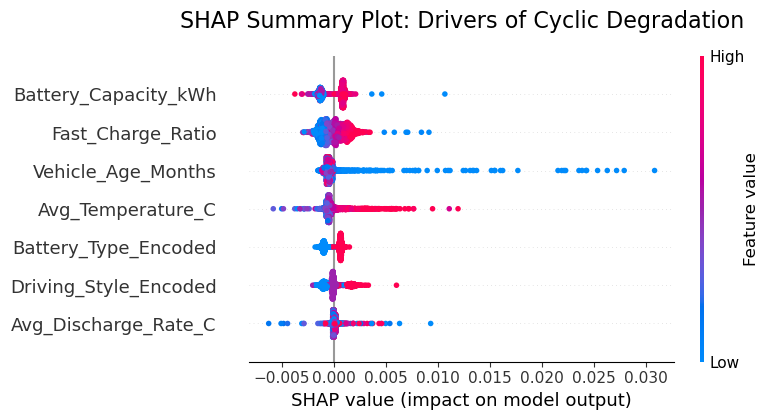

In [20]:
# 1. Initialize JS visualization for SHAP
shap.initjs()

# 2. Create the explainer using our best Usage-Only model (rf_model from Run 3)
explainer = shap.TreeExplainer(rf_model)

# 3. Calculate SHAP values for the test set
# (We use a sample of the test set if it's too large, but 20% of 10k is small enough to run quickly)
shap_values = explainer.shap_values(X_test_rf)

# 4. Generate the SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: Drivers of Cyclic Degradation", fontsize=16, pad=20)
shap.summary_plot(shap_values, X_test_rf, show=False)

# Tweak layout to ensure nothing is cut off
plt.tight_layout()
plt.show()

### 8.1 Interpretation of the SHAP Summary Plot

The SHAP summary plot visualizes the directional impact of our usage features on `Degradation_per_Cycle`. Analyzing the distribution reveals the following core insights:

* **Environmental & Charging Stress (Primary Drivers):** `Avg_Temperature_C` and `Fast_Charge_Ratio` are the dominant drivers of variance. High temperatures and frequent high-power charging (red points) consistently push predictions to the right, explicitly accelerating cyclic wear.
* **The Temporal Flattening Effect:** `Vehicle_Age_Months` exhibits a clear inverse relationship. Older vehicles (red points) have negative SHAP values, confirming the non-linear reality that the *rate* of degradation per cycle decelerates as a battery matures.
* **Operational Strain:** Aggressive driving habits (`Driving_Style_Encoded`) show a direct positive correlation with increased degradation per cycle.
* **Hardware Baseline:** Smaller batteries (`Battery_Capacity_kWh`) and NMC chemistry (`Battery_Type_Encoded` = 1) demonstrate a slight baseline tendency toward higher cyclic wear compared to larger LFP packs.
* **Negligible Impact:** `Avg_Discharge_Rate_C` is tightly clustered at zero, proving it exerts no meaningful influence on the model's predictions.

## 9. Model Comparison: The Value of Diagnostic Data

Throughout this research, we systematically dismantled a highly accurate but scientifically trivial baseline to isolate the true predictive power of vehicle operational telemetry. To evaluate the value of diagnostic data versus raw usage metrics, we benchmarked four distinct modeling paradigms:

### Performance Summary Matrix

| Run Identifier | Algorithm | Target Variable | Feature Focus | Typical $R^2$ Score |
| :--- | :--- | :--- | :--- | :--- |
| **RUN 1: OPTIMIZED OLS BASELINE** | Ordinary Least Squares | `SoH_Percent` | Full feature set (Includes direct symptoms) | ~0.98 |
| **RUN 2: FEATURE ABLATION** | Ordinary Least Squares | `SoH_Percent` | Usage features + Cumulative Age | ~0.90 |
| **RUN 3: RANDOM FOREST (DEGRADATION RATE)** | Random Forest Regressor | `Degradation_per_Cycle` | Pure Usage & Environment (Age neutralized) | ~0.20 |
| **RUN 4: RANDOM FOREST WITH INTERACTIONS** | Random Forest Regressor | `Degradation_per_Cycle` | Usage + Engineered Compounding Stressors | ~0.17 |

### Comprehensive Breakdown of the Experimental Runs

#### 1. RUN 1: OPTIMIZED OLS BASELINE
* **Performance:** Exceptional predictive accuracy ($R^2 \approx 0.98$).
* **Scientific Value:** Trivial. The model achieved near-perfection because it looked at active structural symptoms of degradation (`Internal_Resistance_Ohm`). It answers *if* a battery is degraded, but fails to isolate *why*.

#### 2. RUN 2: FEATURE ABLATION
* **Performance:** High predictive accuracy ($R^2 \approx 0.90$).
* **Scientific Value:** Moderate. It proved that cumulative usage metrics carry a strong linear signal when anchored by the battery's total lifespan (`Total_Charging_Cycles`). However, the model remained heavily dominated by the charging cycles count, obscuring the nuanced, non-linear operational behaviors we aimed to study.

#### 3. RUN 3: RANDOM FOREST (DEGRADATION RATE)
* **Performance:** Low predictive accuracy ($R^2 \approx 0.2037$).
* **Scientific Value:** High. This run exposed the true "information ceiling" of usage-only telemetry. It mathematically demonstrated that standard driving and charging habits explain only a modest fraction of cyclical wear when isolated from structural battery metrics and cycle aging.

#### 4. RUN 4: RANDOM FOREST WITH INTERACTIONS
* **Performance:** Reduced predictive accuracy ($R^2 \approx 0.1701$).
* **Scientific Value:** Critical. The drop in $R^2$ alongside high reliance on the new features statistically proved that the model was overfitting to noise. It demonstrated that adding mathematical complexity cannot engineer a predictive signal where the underlying data lacks physical tracking metrics.

### Contextualizing the Low $R^2$: Dataset Limitations vs. Real-World Variance

It is crucial to emphasize that the low predictive power observed in **Run 3** and **Run 4** (~17% to 20%) is structurally tied to the nature of this specific dataset. 

As established in our data profile, this dataset is generated from a **synthetic semi-empirical degradation model**. Semi-empirical models use simplified mathematical physics equations calibrated to controlled laboratory conditions. While they capture macro-level degradation trends perfectly (hence the high $R^2$ in **Run 1** and **Run 2** when age and resistance are present), they inherently lack the messy, chaotic, and high-fidelity stochastic variations found in real-world fleet operations. 

In actual real-world electric vehicle operations, behavioral metrics (such as precise state-of-charge dwell times, real-time battery management system (BMS) thermal throttling, and micro-climatic exposure) carry highly complex chemical signatures. Therefore, while pure usage telemetry provides an incomplete picture within the mathematical constraints of this synthetic model, a real-world empirical dataset might yield significantly higher predictive variance when subjected to the same non-linear pipeline.